In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.utils import encoding
import math



In [102]:
patientData = pd.read_csv('/content/patients_csv.csv', encoding='latin1')
print(patientData.shape)
medicalData = pd.read_csv('/content/Cleaned_Medications.csv')
print(medicalData.shape)
df = medicalData.merge(patientData, left_on='PATIENT', right_on='Patient id', how='inner')
df.head()

(108, 22)
(3850, 13)


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,2/5/2018 14:22,2/5/2018 14:22,cc3eac4a-34a7-9a15-1522-8087135631b7,0133f751-9229-3cfd-815f-b6d4979bdd6a,cc3eac4a-34a7-9a15-197d-c8faa82aee51,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,...,North Brookfield,Massachusetts,Worcester County,25027.0,1535,42.267480,-72.105242,104532.20,18048.65,42283
1,2/10/2020 13:11,2/10/2020 13:11,cc3eac4a-34a7-9a15-1522-8087135631b7,0133f751-9229-3cfd-815f-b6d4979bdd6a,cc3eac4a-34a7-9a15-88f3-730564694133,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,...,North Brookfield,Massachusetts,Worcester County,25027.0,1535,42.267480,-72.105242,104532.20,18048.65,42283
2,2/14/2022 13:09,2/14/2022 13:09,cc3eac4a-34a7-9a15-1522-8087135631b7,0133f751-9229-3cfd-815f-b6d4979bdd6a,cc3eac4a-34a7-9a15-473f-34cd7ed0707a,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,...,North Brookfield,Massachusetts,Worcester County,25027.0,1535,42.267480,-72.105242,104532.20,18048.65,42283
3,11/29/2025 15:35,12/13/2025 15:35,cc3eac4a-34a7-9a15-1522-8087135631b7,734afbd6-4794-363b-9bc0-6a3981533ed5,cc3eac4a-34a7-9a15-a77a-027dab52c156,562251,Amoxicillin 250 MG / Clavulanate 125 MG Oral T...,529.35,0.00,1,...,North Brookfield,Massachusetts,Worcester County,25027.0,1535,42.267480,-72.105242,104532.20,18048.65,42283
4,6/17/2021 7:02,6/17/2021 21:02,8b9df7af-24b3-66ee-afeb-2734ebcbd33c,df166300-5a78-3502-a46a-832842197811,8b9df7af-24b3-66ee-5ca7-72a6a1f9f6bc,198335,sulfamethoxazole 800 MG / trimethoprim 160 MG ...,129.94,79.94,1,...,Bedford,Massachusetts,Middlesex County,25017.0,1730,42.539821,-71.256841,98009.84,531508.43,33657


In [103]:
df.shape

(3850, 35)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3850 entries, 0 to 3849
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   START                3850 non-null   object 
 1   STOP                 3850 non-null   object 
 2   PATIENT              3850 non-null   object 
 3   PAYER                3850 non-null   object 
 4   ENCOUNTER            3850 non-null   object 
 5   CODE                 3850 non-null   int64  
 6   DESCRIPTION          3850 non-null   object 
 7   BASE_COST            3850 non-null   float64
 8   PAYER_COVERAGE       3850 non-null   float64
 9   DISPENSES            3850 non-null   int64  
 10  TOTALCOST            3850 non-null   float64
 11  REASONCODE           3850 non-null   float64
 12  REASONDESCRIPTION    3850 non-null   object 
 13  Patient id           3850 non-null   object 
 14  BIRTHDATE            3850 non-null   object 
 15  DEATHDATE            443 non-null    o

# **Descriptive Statistics**

In [105]:
numeric_cols = ['BASE_COST', 'PAYER_COVERAGE', 'TOTALCOST', 'DISPENSES']

stats_summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Mode': df[numeric_cols].mode().iloc[0]

})

print("--- Summary Statistics for Financial & Dispense Metrics ---\n")
print(stats_summary.round(2))

--- Summary Statistics for Financial & Dispense Metrics ---

                   Mean  Median   Std Dev   Min        Max       Range    Mode
BASE_COST        124.75   34.56   1484.41  0.01    91728.0    91727.99  129.94
PAYER_COVERAGE    69.59    0.36   1187.38  0.00    73382.4    73382.40    0.00
TOTALCOST       2986.58   61.15  95035.95  0.01  5870592.0  5870591.99  129.94
DISPENSES         10.17    1.00     47.66  1.00      861.0      860.00    1.00


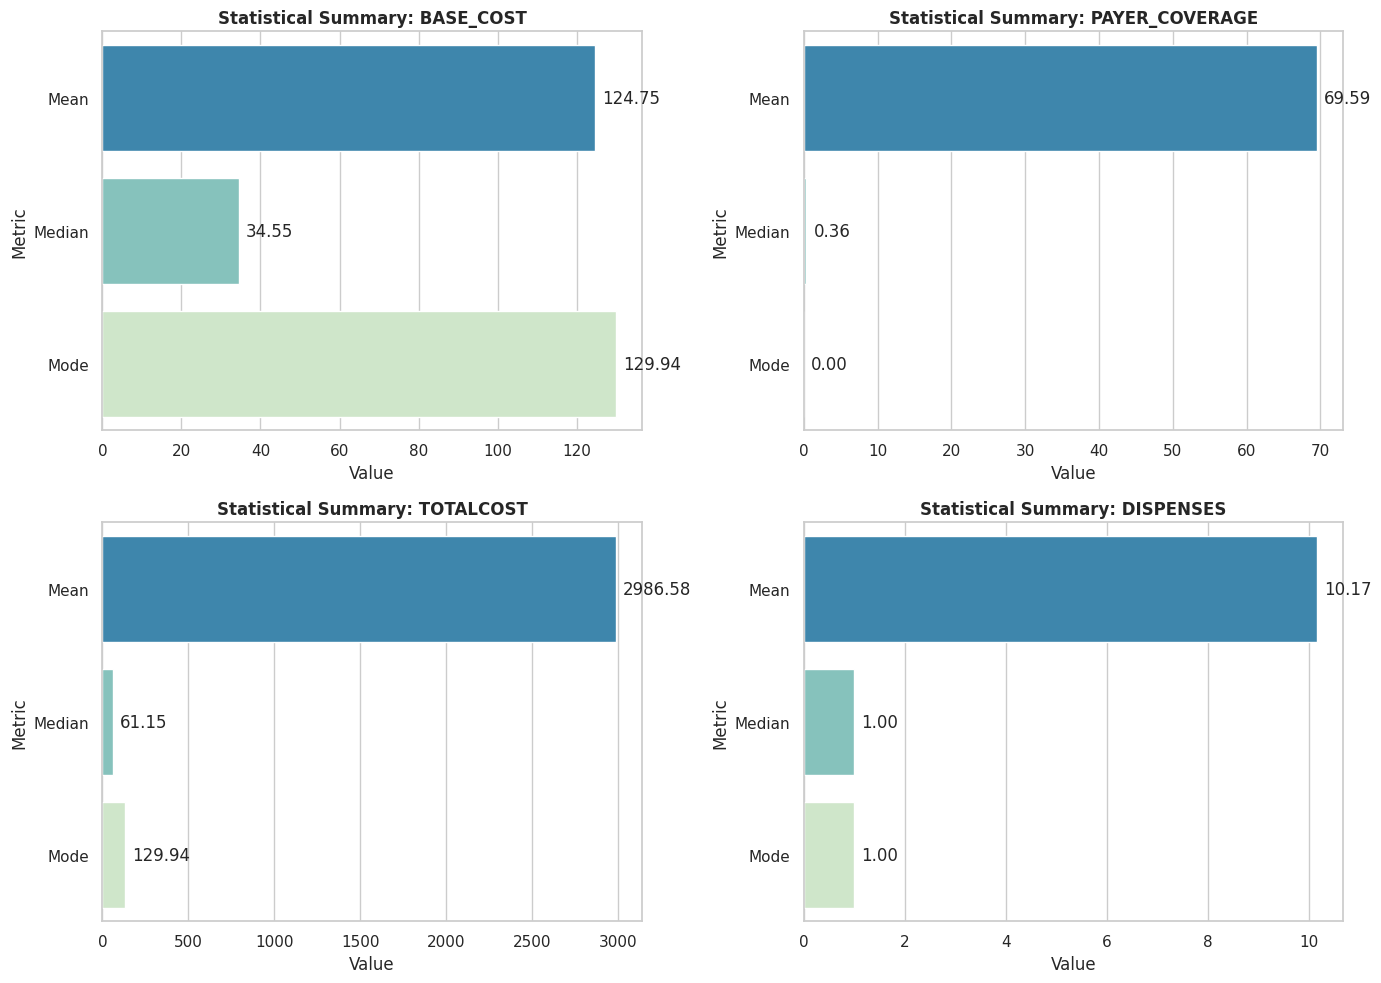

In [106]:
# Set plot theme
sns.set_theme(style="whitegrid")

# Selected metrics to display on each plot
metrics_to_plot = ['Mean', 'Median', 'Mode']
import math

# Get numeric columns from stats_summary
cols = stats_summary.index.tolist()
num_cols = len(cols)

# Set number of grid columns and calculate rows
ncols = 2
nrows = math.ceil(num_cols / ncols)

# Initialize figure BEFORE the loop
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

# Iterate over each column and build its individual statistical plot
for i, col in enumerate(cols):
    col_data = stats_summary.loc[col, metrics_to_plot]

    # Create horizontal bar plot
    sns.barplot(
        x=col_data.values,
        y=col_data.index,
        hue=col_data.index,
        palette="GnBu_r",
        legend=False,
        ax=axes[i]
    )

    # Add numerical labels on bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].annotate(
            f'{width:.2f}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            xytext=(5, 0),
            textcoords='offset points'
        )
        axes[i].set_title(f'Statistical Summary: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Metric')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Outlier Analysis**

**Outlier Analysis for TOTALCOST from medications table**

In [107]:
# Set overall visualization theme
sns.set_theme(style="whitegrid")

# Function to detect and extract outliers using IQR
def detect_iqr_outliers(data_frame, column_name):
    Q1 = data_frame[column_name].quantile(0.25)
    Q3 = data_frame[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = data_frame[(data_frame[column_name] < lower_bound) | (data_frame[column_name] > upper_bound)]

    print(f"--- Outlier Summary for {column_name} ---")
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Upper Bound threshold: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)} ({len(outliers) / len(data_frame) * 100:.2f}%)")

    return outliers, upper_bound

# Run outlier detection on TOTALCOST
totalcost_outliers, upper_threshold = detect_iqr_outliers(df, 'TOTALCOST')

print("\n--- Top 10 High-Cost Outlier Medications ---")
df.groupby('DESCRIPTION').agg(
    total_cost=('TOTALCOST', 'sum'),
    Patient_count=('DESCRIPTION', 'count'),
    Dispenses = ('DISPENSES', 'sum')
).sort_values('total_cost', ascending=False).head(10)

--- Outlier Summary for TOTALCOST ---
Q1 (25th percentile): 3.60
Q3 (75th percentile): 259.88
IQR: 256.28
Upper Bound threshold: 644.30
Number of Outliers: 393 (10.21%)

--- Top 10 High-Cost Outlier Medications ---


,total_cost,Patient_count,Dispenses
DESCRIPTION,,,
Alteplase 100 MG Injection,5870592.00,1,64
Clopidogrel 75 MG Oral Tablet,1007815.61,13,1780
aspirin 81 MG Oral Capsule [Vazalore],702065.82,21,5403
NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Injector,428978.17,16,3670
diphenhydrAMINE Hydrochloride 25 MG Oral Tablet,298018.52,3,2129
Simvastatin 20 MG Oral Tablet,253556.87,13,1780
24 HR metoprolol succinate 100 MG Extended Release Oral Tablet,231423.14,14,1781
Fexofenadine hydrochloride 30 MG Oral Tablet,179962.16,3,637
Naproxen sodium 220 MG Oral Tablet,172951.40,22,1301


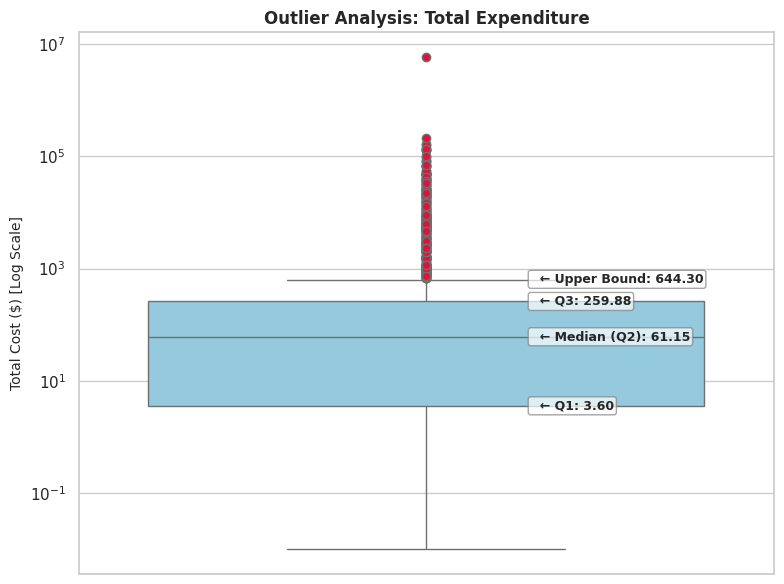

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Boxplot for TOTALCOST in medications table
sns.boxplot(
    data=df,
    y='TOTALCOST',
    color='skyblue' ,
    flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6)
)

plt.yscale('log')

series = df['TOTALCOST'].dropna()
q1 = series.quantile(0.25)
median = series.median()
q3 = series.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

x_pos = 0.15

# Write the statistics above the graph
if q1 > 0:
    plt.text(x_pos, q1, f'  ← Q1: {q1:,.2f}', verticalalignment='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='gray'))

if median > 0:
    plt.text(x_pos, median, f'  ← Median (Q2): {median:,.2f}', verticalalignment='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='gray'))

if q3 > 0:
    plt.text(x_pos, q3, f'  ← Q3: {q3:,.2f}', verticalalignment='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='gray'))

if upper_bound > 0:
    plt.text(x_pos, upper_bound, f'  ← Upper Bound: {upper_bound:,.2f}', verticalalignment='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='gray'))

plt.title('Outlier Analysis: Total Expenditure', fontsize=12, fontweight='bold')
plt.ylabel('Total Cost ($) [Log Scale]', fontsize=10)

plt.tight_layout()
plt.show()

**Outlier analysis for TOTAL_CLAIM_COST form encounters table**

number of outliers: 97 from 1000


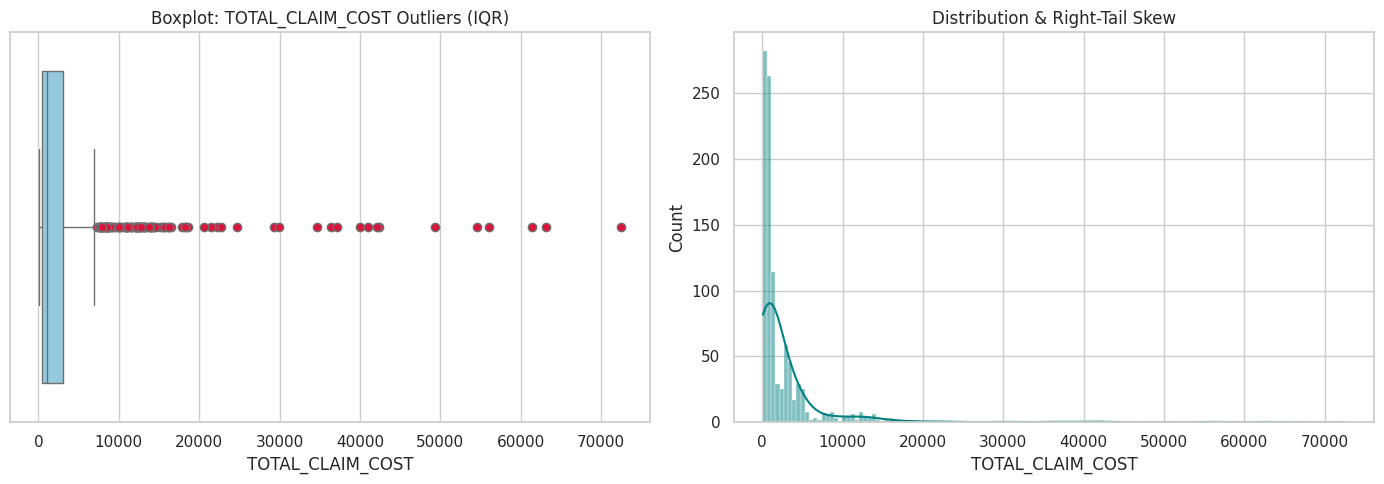

In [109]:
encounters = pd.read_csv('/content/encounters_csv.csv', parse_dates=['START','STOP'])
Q1 = encounters['TOTAL_CLAIM_COST'].quantile(0.25)
Q3 = encounters['TOTAL_CLAIM_COST'].quantile(0.75)
IQR = Q3 - Q1
outliers = encounters[(encounters['TOTAL_CLAIM_COST'] > Q3 + 1.5*IQR)]
print(f"number of outliers: {len(outliers)} from {len(encounters)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. Boxplot (Primary)
sns.boxplot(data=encounters, x='TOTAL_CLAIM_COST', ax=axes[0], color='skyblue',     flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6)
)
axes[0].set_title('Boxplot: TOTAL_CLAIM_COST Outliers (IQR)')

# 2. Histogram / KDE (Supporting Distribution)
sns.histplot(data=encounters, x='TOTAL_CLAIM_COST', kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution & Right-Tail Skew')

plt.tight_layout()
plt.show()

**Payer Performance**

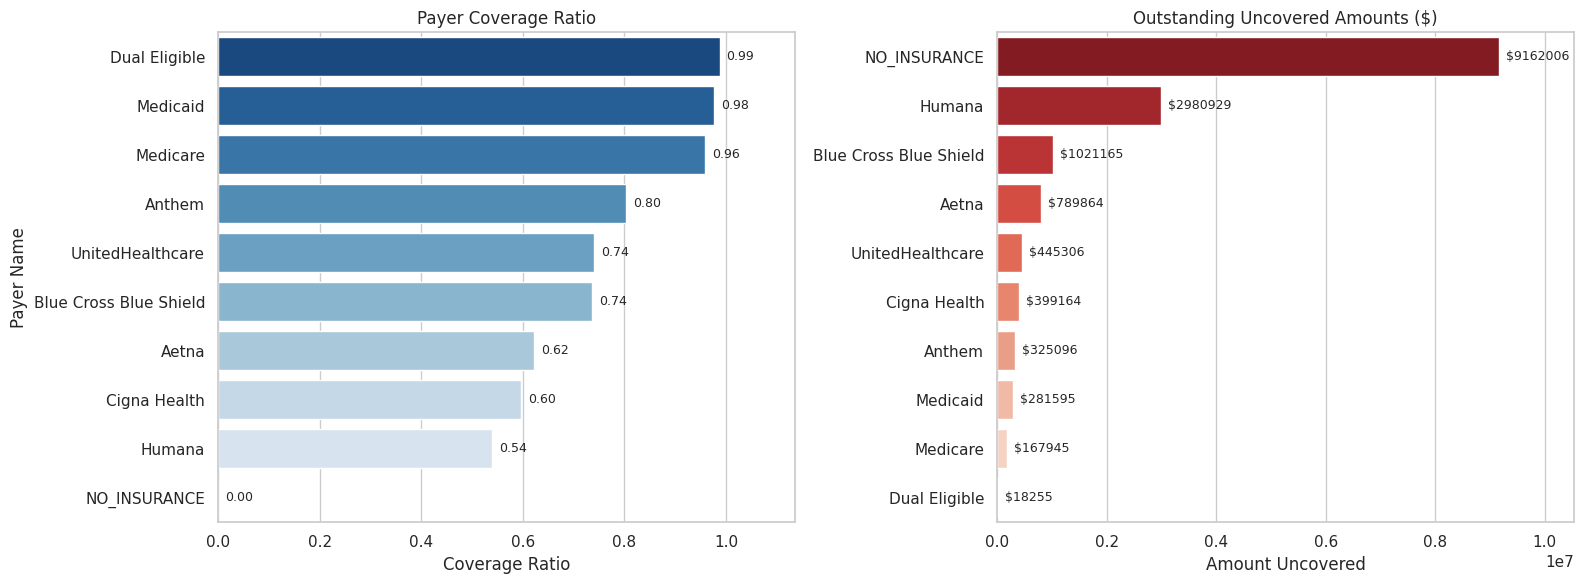

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

claims_tx = pd.read_csv('/content/claims_transactions_csv.csv', parse_dates=['FROMDATE', 'TODATE'])
payers = pd.read_csv('/content/payers_csv.csv')

payers['coverage_ratio'] = payers['AMOUNT_COVERED'] / (payers['AMOUNT_COVERED'] + payers['AMOUNT_UNCOVERED'])

payers_sorted = payers.sort_values('coverage_ratio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = sns.barplot(data=payers_sorted, y='NAME', x='coverage_ratio', ax=axes[0], palette='Blues_r', hue='NAME', legend=False)
axes[0].set_title('Payer Coverage Ratio')
axes[0].set_xlabel('Coverage Ratio')
axes[0].set_ylabel('Payer Name')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=5, fontsize=9)

payers_uncovered = payers.sort_values('AMOUNT_UNCOVERED', ascending=False)
ax2 = sns.barplot(data=payers_uncovered, y='NAME', x='AMOUNT_UNCOVERED', ax=axes[1], palette='Reds_r', hue='NAME', legend=False)
axes[1].set_title('Outstanding Uncovered Amounts ($)')
axes[1].set_xlabel('Amount Uncovered')
axes[1].set_ylabel('')

for container in ax2.containers:
    ax2.bar_label(container, fmt='$%.0f', padding=5, fontsize=9)

axes[0].set_xlim(0, payers_sorted['coverage_ratio'].max() * 1.15)
axes[1].set_xlim(0, payers_uncovered['AMOUNT_UNCOVERED'].max() * 1.15)

plt.tight_layout()
plt.show()

# **Correlation Analysis**

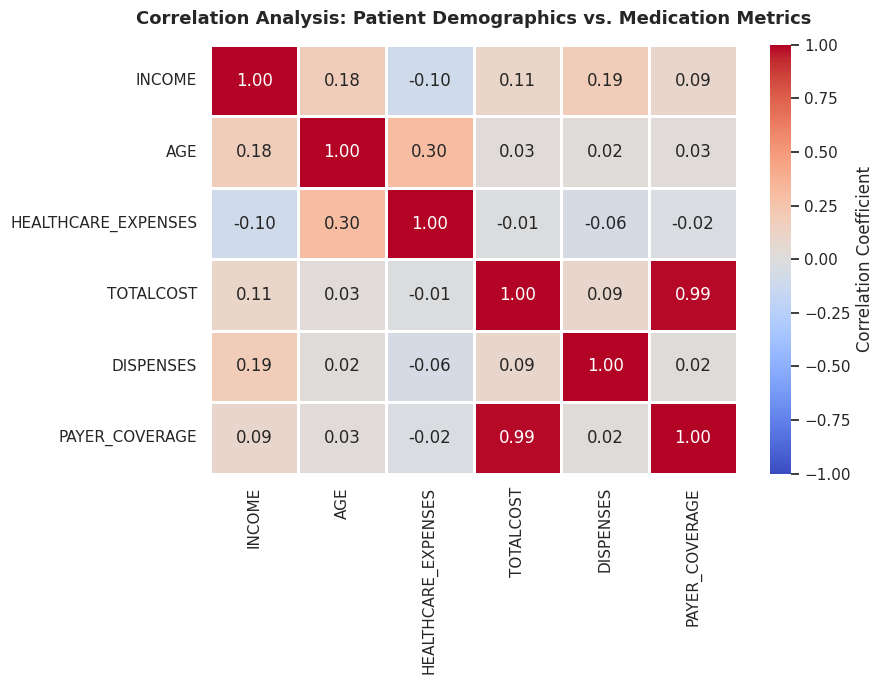

In [111]:
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
end_date = pd.to_datetime(df['DEATHDATE']).fillna(pd.to_datetime('today'))
df['AGE'] = ((end_date - df['BIRTHDATE']).dt.days / 365).astype(int)

selected_cols = [
    'INCOME',
    'AGE',
    'HEALTHCARE_EXPENSES',
    'TOTALCOST',
    'DISPENSES',
    'PAYER_COVERAGE',
]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    cbar_kws={'label': 'Correlation Coefficient'},
)

plt.title(
    'Correlation Analysis: Patient Demographics vs. Medication Metrics',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

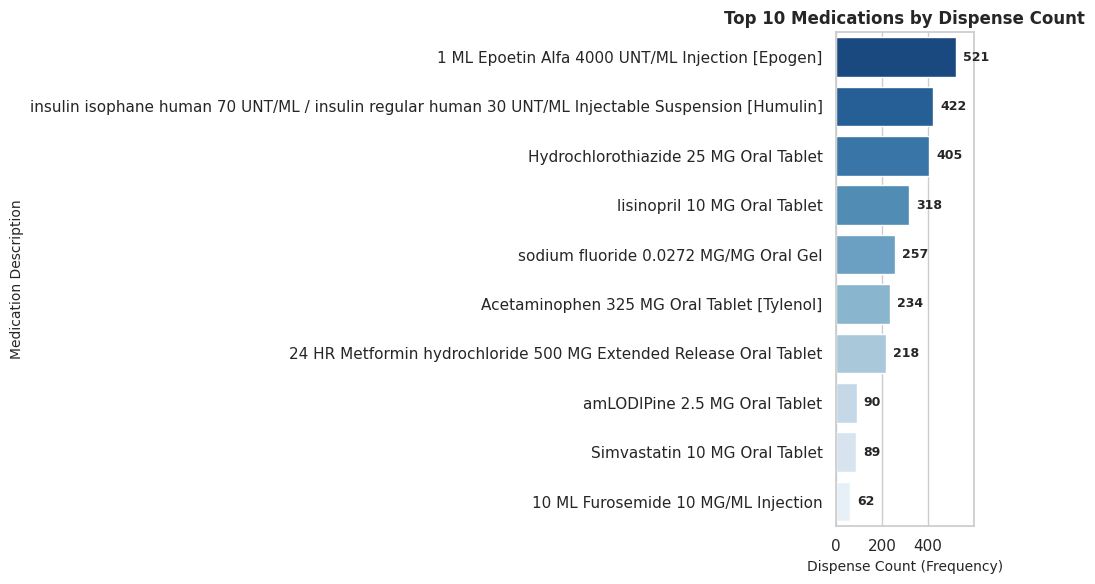

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_medications = pd.read_csv('/content/Cleaned_Medications.csv')

top_meds_count = (
    cleaned_medications.groupby('DESCRIPTION')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_meds_count,
    y='DESCRIPTION',
    x='count',
    hue='DESCRIPTION',
    legend=False,
    palette='Blues_r'
)

plt.title('Top 10 Medications by Dispense Count', fontsize=12, fontweight='bold')
plt.xlabel('Dispense Count (Frequency)', fontsize=10)
plt.ylabel('Medication Description', fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=9, fontweight='bold')

plt.xlim(0, top_meds_count['count'].max() * 1.15)

plt.tight_layout()
plt.show()

# **Time-Series Forecating**

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Month 1: 14.31
Predicted Month 2: 14.36
Predicted Month 3: 14.41
Predicted Month 4: 14.46
Predicted Month 5: 14.51
Predicted Month 6: 14.56


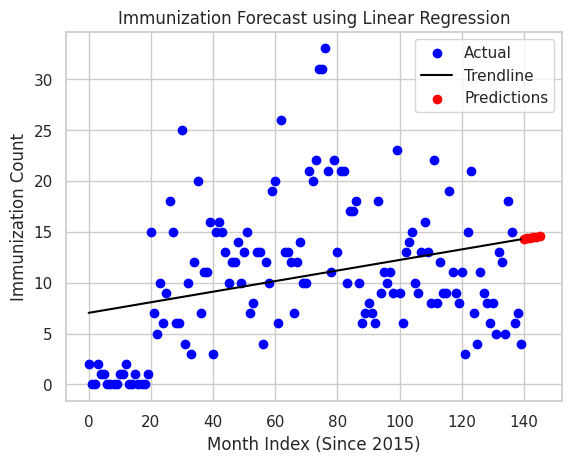

In [113]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

immunizations = pd.read_csv('immunizations.csv', parse_dates=['DATE'])

monthly_imm = immunizations.set_index('DATE').resample('ME').size().reset_index()
monthly_imm.columns = ['DATE', 'Immunization_Count']
monthly_imm = monthly_imm[monthly_imm['DATE'] >= '2015-01-01'].reset_index(drop=True)

monthly_imm['Month_Index'] = monthly_imm.index

X = monthly_imm[['Month_Index']]
y = monthly_imm['Immunization_Count']

model = LinearRegression()
model.fit(X, y)

last_index = monthly_imm['Month_Index'].max()
future_indices = np.array([[last_index + i] for i in range(1, 7)])

predictions = model.predict(future_indices)

for i, pred in enumerate(predictions, 1):
    print(f"Predicted Month {i}: {pred:.2f}")

plt.scatter(X['Month_Index'], y, color='blue', label='Actual')
plt.plot(X['Month_Index'], model.predict(X), color='black', label='Trendline')
plt.scatter(future_indices, predictions, color='red', label='Predictions')
plt.xlabel('Month Index (Since 2015)')
plt.ylabel('Immunization Count')
plt.title('Immunization Forecast using Linear Regression')
plt.legend()
plt.show()



# **Classification**

In [114]:
df_enc = pd.read_csv('/content/encounters.csv')
df_enc.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,cc3eac4a-34a7-9a15-13f3-57f4a6b934f9,1996-03-11T08:35:36Z,1996-03-11T09:21:33Z,cc3eac4a-34a7-9a15-1522-8087135631b7,a3327df4-d092-350b-b551-e60c82076c9a,a7db224a-b937-3e39-be28-5431d106bfdb,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.8,704.20,0.0,NaN,NaN
1,cc3eac4a-34a7-9a15-1dc5-a353457420c6,2006-03-27T08:35:36Z,2006-03-27T09:29:36Z,cc3eac4a-34a7-9a15-1522-8087135631b7,a3327df4-d092-350b-b551-e60c82076c9a,a7db224a-b937-3e39-be28-5431d106bfdb,734afbd6-4794-363b-9bc0-6a3981533ed5,wellness,162673000,General examination of patient (procedure),136.8,1300.91,0.0,NaN,NaN
2,cc3eac4a-34a7-9a15-94b5-26ac8c6c7134,2009-03-30T08:35:36Z,2009-03-30T09:25:14Z,cc3eac4a-34a7-9a15-1522-8087135631b7,a3327df4-d092-350b-b551-e60c82076c9a,a7db224a-b937-3e39-be28-5431d106bfdb,734afbd6-4794-363b-9bc0-6a3981533ed5,wellness,162673000,General examination of patient (procedure),136.8,1275.50,0.0,NaN,NaN
3,cc3eac4a-34a7-9a15-2a3d-1a1ba491a8ac,2012-04-02T08:35:36Z,2012-04-02T09:18:03Z,cc3eac4a-34a7-9a15-1522-8087135631b7,a3327df4-d092-350b-b551-e60c82076c9a,a7db224a-b937-3e39-be28-5431d106bfdb,0133f751-9229-3cfd-815f-b6d4979bdd6a,wellness,162673000,General examination of patient (procedure),136.8,934.74,0.0,NaN,NaN
4,cc3eac4a-34a7-9a15-99df-e3a0393fa95e,2015-04-06T08:35:36Z,2015-04-06T09:07:26Z,cc3eac4a-34a7-9a15-1522-8087135631b7,a3327df4-d092-350b-b551-e60c82076c9a,a7db224a-b937-3e39-be28-5431d106bfdb,0133f751-9229-3cfd-815f-b6d4979bdd6a,wellness,162673000,General examination of patient (procedure),136.8,860.16,0.0,NaN,NaN


In [115]:
# 1. import all libs needed
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler


# 2. Feature Engineering for start and stop date
df_enc['START'] = pd.to_datetime(df_enc['START'])
df_enc['STOP'] = pd.to_datetime(df_enc['STOP'])

# 3. Calculate the Duration by minutes
df_enc['DURATION_MINUTES'] = (
    df_enc['STOP'] - df_enc['START']
).dt.total_seconds() / 60.0
df_enc['START_HOUR'] = df_enc['START'].dt.hour

#  4. Filter rare classes to protect Cross-Validation and Data Splitting
class_counts = df_enc['ENCOUNTERCLASS'].value_counts()
frequent_classes = class_counts[class_counts >= 5].index
df_filtered = df_enc[df_enc['ENCOUNTERCLASS'].isin(frequent_classes)].copy()

# 5. Define the features and the target
X = df_filtered[[
    'TOTAL_CLAIM_COST',
    'PAYER_COVERAGE',
    'BASE_ENCOUNTER_COST',
    'DURATION_MINUTES',
    'START_HOUR',
    'PAYER',
    'REASONDESCRIPTION',
]]
y = df_filtered['ENCOUNTERCLASS']

# 6. Encode the taget column
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 7. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 8. Split the features into numeric and categorical data
numeric_features = [
    'TOTAL_CLAIM_COST',
    'PAYER_COVERAGE',
    'BASE_ENCOUNTER_COST',
    'DURATION_MINUTES',
    'START_HOUR',
]
categorical_features = ['PAYER', 'REASONDESCRIPTION']

# 9. Make pipeline for numeric data
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# 10. Make pipeline for categorical data
categorical_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='constant', fill_value='Unknown'),),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False),),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# 11. full pipeline
full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight='balanced_subsample',
            ),
        ),
    ]
)

# 12. train the model and predict on the tested data
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)


acc = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, zero_division=0
)
print("Model Accuracy:", acc)


report_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
})

print("\n=== Summary Report Table ===")
print(report_df.round(4).to_string(index=False))


Model Accuracy: 0.9865470852017937

=== Summary Report Table ===
     Class  Precision  Recall  F1-Score  Support
ambulatory     0.9800  0.9983    0.9890      588
 emergency     1.0000  1.0000    1.0000       54
      home     1.0000  1.0000    1.0000       13
   hospice     1.0000  1.0000    1.0000        2
 inpatient     1.0000  1.0000    1.0000       12
outpatient     0.9930  0.9342    0.9627      152
       snf     1.0000  1.0000    1.0000        2
urgentcare     1.0000  0.9744    0.9870       39
   virtual     0.0000  0.0000    0.0000        1
  wellness     0.9921  0.9921    0.9921      252


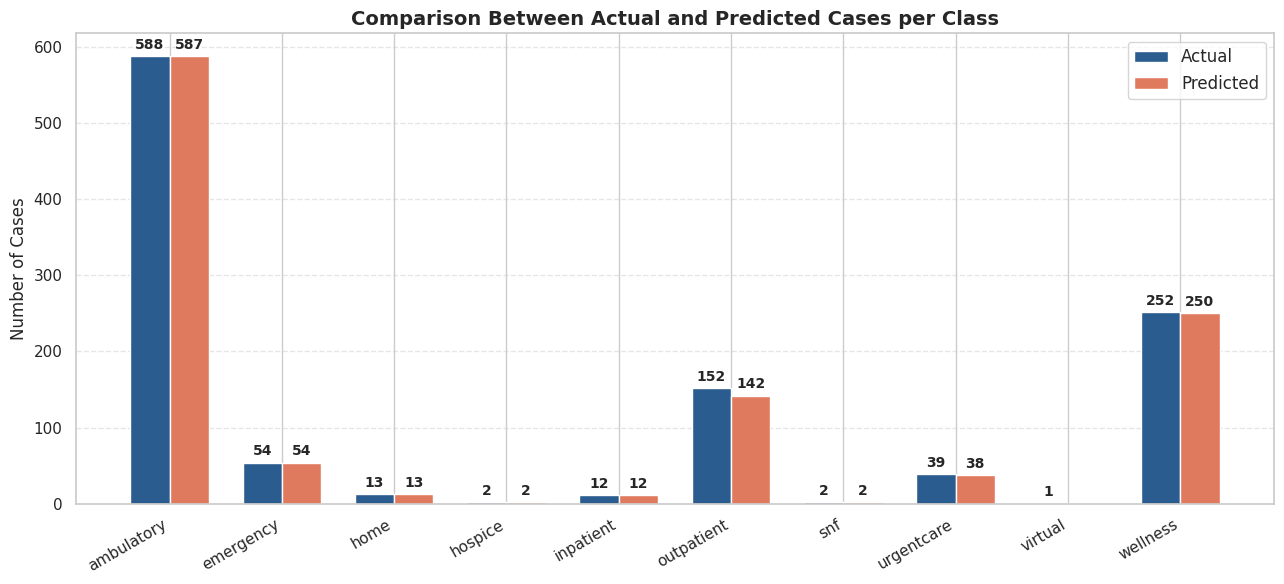

In [116]:
cm = confusion_matrix(y_test, y_pred)
classes = label_encoder.classes_
actual_counts = cm.sum(axis=1)
correct_predictions = np.diag(cm)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

rects1 = ax.bar(
    x - width / 2,
    actual_counts,
    width,
    label='Actual',
    color='#2b5c8f',
)
rects2 = ax.bar(
    x + width / 2,
    correct_predictions,
    width,
    label='Predicted',
    color='#e07a5f',
)

ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title(
    'Comparison Between Actual and Predicted Cases per Class',
    fontsize=14,
    fontweight='bold',
)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)


# type the number above each bar
def autolabel(rects):
  for rect in rects:
    height = rect.get_height()
    if height > 0:
      ax.annotate(
          f'{height}',
          xy=(rect.get_x() + rect.get_width() / 2, height),
          xytext=(0, 3),
          textcoords='offset points',
          ha='center',
          va='bottom',
          fontsize=10,
          fontweight='bold',
      )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# **Regression**

=== Regression Performance ===
R² Score: 0.7763
MAE: $ 21395.02


/tmp/ipykernel_1903/1615892304.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


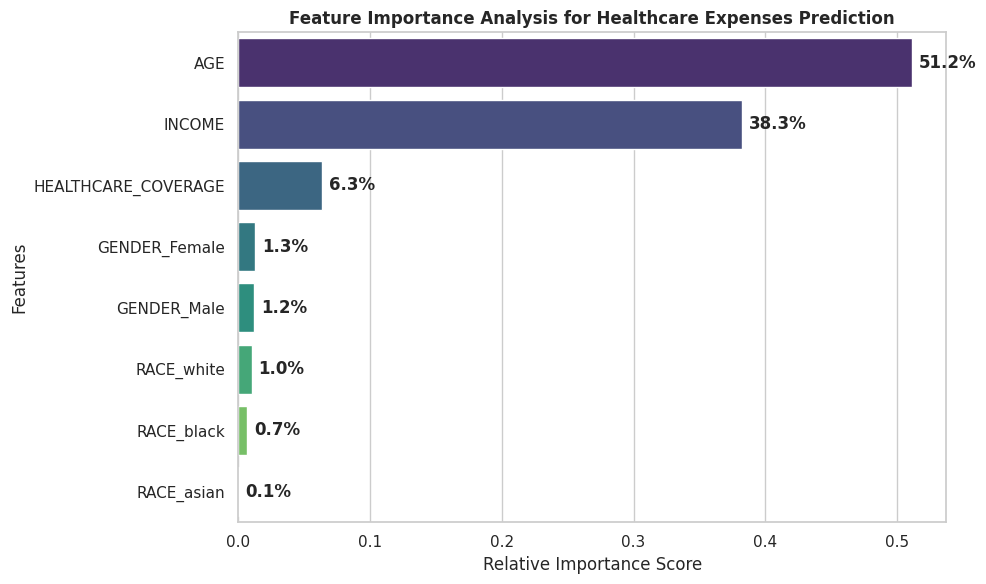

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/content/patients_csv.csv', encoding='latin1')

# Calculate the age of each patient
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
df['DEATHDATE'] = pd.to_datetime(df['DEATHDATE'])
ref_date = df['DEATHDATE'].fillna(pd.Timestamp('2024-01-01'))
df['AGE'] = ((ref_date - df['BIRTHDATE']).dt.days / 365.25).astype(int)


numeric_features = ['AGE', 'INCOME', 'HEALTHCARE_COVERAGE']
categorical_features = ['GENDER', 'RACE']

# Features & Target
X = df[numeric_features + categorical_features]
y = np.log1p(df['HEALTHCARE_EXPENSES'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

full_pipeline.fit(X_train, y_train)
y_pred_log = full_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)


print("=== Regression Performance ===")
print("R² Score:", round(r2_score(y_test_orig, y_pred), 4))
print("MAE: $", round(mean_absolute_error(y_test_orig, y_pred), 2))


# Feature Importance Matrix Extraction & Visualization
cat_encoder = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_features)

importances = full_pipeline.named_steps['regressor'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

for i, value in enumerate(feature_importance_df['Importance']):
    plt.text(value + 0.005, i, f"{value*100:.1f}%", va='center', fontweight='bold')

plt.title('Feature Importance Analysis for Healthcare Expenses Prediction', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **Clustering**

In [118]:
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Define numeric and categrocal columns
num_features = ['HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
cat_features = ['GENDER', 'RACE']

# 2. Define the features
X = patientData[num_features + cat_features]

# 3. preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False),cat_features),
    ]
)

X_processed = preprocessor.fit_transform(X)

# 4. Full Pipeline
final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('clusterer', KMeans(n_clusters=3, random_state=42, n_init=10)),
    ]
)

# 5. Predict the model and put the result to the dataFrame
patientData['Cluster'] = final_pipeline.fit_predict(X)

print(patientData['Cluster'].value_counts())


Cluster
0    68
1    33
2     7
Name: count, dtype: int64


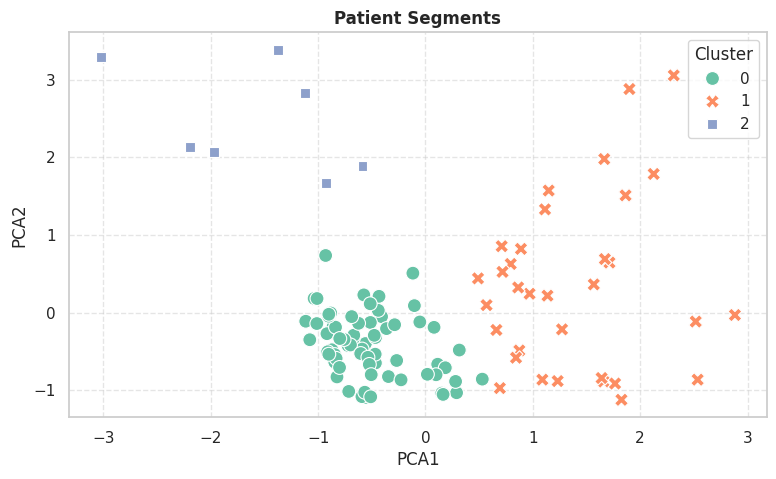

In [119]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

patientData['PCA1'] = X_pca[:, 0]
patientData['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=patientData,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    style='Cluster',
    palette='Set2',
    s=100,
)
plt.title('Patient Segments', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **NLP**

In [120]:
#  1. Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv('/content/careplans.csv')

# 2. Clean the data by remove null rows
df = df.dropna(subset=['REASONDESCRIPTION', 'DESCRIPTION'])

X = df['REASONDESCRIPTION']  # Dignose
y = df['DESCRIPTION']        # Care Plan

# 3. Split the data into 80%- 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Transform the word into numbers by TF-IDF (Vectorization)
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 5. Train the model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 6. Evaluate the model
y_pred = model.predict(X_test_tfidf)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,zero_division=0))



new_reason = ["Patient is a 54-year-old male presenting with chronic fatigue, increased thirst, and a long history of Diabetes mellitus type 2."]
new_reason_tfidf = vectorizer.transform(new_reason)
predicted_careplan = model.predict(new_reason_tfidf)

print(f"\nPredicted Care Plan for '{new_reason[0]}': {predicted_careplan[0]}")

Model Accuracy: 0.9714285714285714

Classification Report:
                                                            precision    recall  f1-score   support

                  Asthma self management (regime/therapy)       1.00      1.00      1.00         2
                              Care plan (record artifact)       1.00      1.00      1.00         2
          Diabetes self management plan (record artifact)       0.89      1.00      0.94         8
                    Discharge care plan (record artifact)       0.00      0.00      0.00         1
                           Fracture care (regime/therapy)       1.00      1.00      1.00         3
              Head injury rehabilitation (regime/therapy)       1.00      1.00      1.00         4
Hyperlipidemia clinical management plan (record artifact)       1.00      1.00      1.00         2
   Lifestyle education regarding hypertension (procedure)       1.00      1.00      1.00         4
                    Musculoskeletal care (regime


Text Input: Patient is an elderly female admitted after a heavy fall, complaining of severe pain and a suspected wrist fracture.
Predicted Risk Level: High


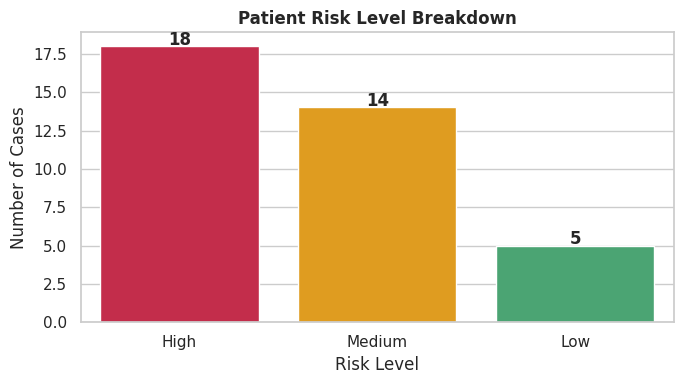

In [121]:
df = df.dropna(subset=['REASONDESCRIPTION']).drop_duplicates(subset=['REASONDESCRIPTION'])

# Function to assign Medical Risk Level based on Diagnosis/Reason
def assign_risk(text):
    text = str(text).lower()

    # 1. High Risk
    if any(word in text for word in ['fracture', 'concussion', 'pulmonary', 'aortic', 'laceration', 'traumatic', 'tear']):
        return 'High'

    # 2. Medium Risk
    elif any(word in text for word in ['hypertension', 'diabetes', 'prediabetes', 'hyperlipidemia', 'asthma', 'alzheimer', 'apnea', 'osteoarthritis', 'chronic', 'cystic']):
        return 'Medium'

    # 3. Low Risk
    else:
        return 'Low'

df['Risk_Level'] = df['REASONDESCRIPTION'].apply(assign_risk)


X = df['REASONDESCRIPTION']
y = df['Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

risk_model = LogisticRegression(max_iter=1000)
risk_model.fit(X_train_tfidf, y_train)

y_pred = risk_model.predict(X_test_tfidf)

custom_patient_note = [
    "Patient is an elderly female admitted after a heavy fall, complaining of severe pain and a suspected wrist fracture."
]
custom_tfidf = vectorizer.transform(custom_patient_note)
predicted_risk = risk_model.predict(custom_tfidf)

print(f"\nText Input: {custom_patient_note[0]}")
print(f"Predicted Risk Level: {predicted_risk[0]}")


plt.figure(figsize=(7, 4))
risk_summary = df['Risk_Level'].value_counts()

color_palette = {'High': 'crimson', 'Medium': 'orange', 'Low': 'mediumseagreen'}


sns.barplot(
    x=risk_summary.index,
    y=risk_summary.values,
    hue=risk_summary.index,
    palette=color_palette,
    legend=False
)
for i, count in enumerate(risk_summary.values):
    plt.text(i, count + 0.1, str(count), ha='center', fontweight='bold')

plt.title('Patient Risk Level Breakdown', fontsize=12, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()